<a href="https://colab.research.google.com/github/Sinrez/PythonProjects/blob/main/sinmple_p.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Уравнение системы, например летящего дрона упрощенное: dy/dt = u - 0.5*y

dy/dt - производная: изменение y в единицу времени t (может быть скорость, высота и тд что угодно)

y — текущее значение

u — управляющий сигнал

-0.5*y — "затухание" системы, например ветер, осадки, сопротивление воздуха и тд

P-регулятор:

u = Kp * (setpoint - y)   
управление = Kp * ошибка
setpoint - целевое значение к которому нужно привести систему, в коде и на графике = 15 (условное число в "попугаях")

Чем больше коэффициент Kp, тем меньше ошибка, но если сделать Kp слишком большим — система начнёт колебаться, см kp = 15 резкий прыжок и затухающие колебания




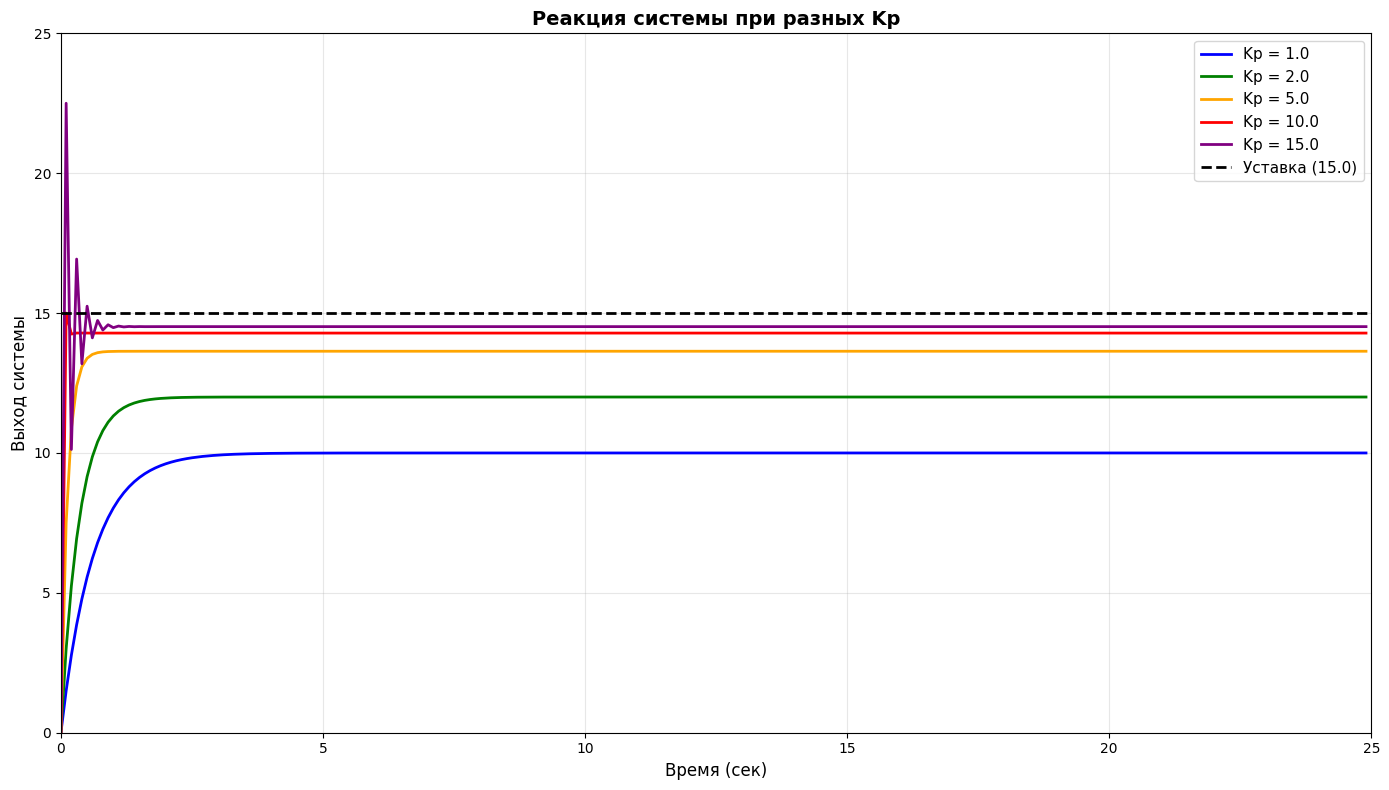

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_system(kp, setpoint=15.0, dt=0.1, time_max=25.0):
    """
    Симулирует систему dy/dt = u - 0.5y с P-регулятором
    Возвращает: время, выход системы, управляющий сигнал
    """
    # Начальное значение системы
    y = 0.0

    time_points = []       # список моментов времени
    system_values = []     # список значений системы в эти моменты
    control_signals = []   # список управляющих сигналов в эти моменты

    for t in np.arange(0, time_max, dt):
        # Сохраняем текущее состояние
        time_points.append(t)
        system_values.append(y)

        # Ошибка = уставка - текущее значение
        error = setpoint - y

        # Управляющий сигнал (P-регулятор)
        u = kp * error
        control_signals.append(u)

        # Обновляем систему: dy/dt = u - 0.5*y
        dy_dt = u - 0.5 * y
        y = y + dy_dt * dt

        # Если становится слишком большим — останавливаем: система в разнос пошла
        if abs(y) > 1000:
            break

    return time_points, system_values, control_signals

#  симуляция для разных коэффициентов Kp
kp_values = [1.0, 2.0, 5.0, 10.0, 15.0]
setpoint = 15.0 #целевое значение системы
plt.figure(figsize=(14, 8))
colors = ['blue', 'green', 'orange', 'red', 'purple']

for kp, color in zip(kp_values, colors):
    time, system, control = simulate_system(kp)
    plt.plot(time, system, label=f'Kp = {kp}', color=color, linewidth=2)

# Добавляем линию уставки - целевая, к которой нужно привести систему
plt.axhline(y=setpoint, color='black', linestyle='--',
            label='Уставка (15.0)', linewidth=2)


plt.xlabel('Время (сек)', fontsize=12)
plt.ylabel('Выход системы', fontsize=12)
plt.title('Реакция системы при разных Kp', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 25)
plt.ylim(0, 25)

plt.tight_layout()
plt.show()

#При Kp = 15 мы видим  затухающие колебания —
#система "перескакивает" уставку, потом возвращается,
#снова чуть перескакивает, и так несколько раз, пока не успокоится.